In [288]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

path = '/Users/isaaclee/Wildfire_Research/sensitivity_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2'

gen_samples = np.load(f"{path}/generated_samples.npz")['arr_0']
gen_mean = np.load(f"{path}/generated_mean_std.npz")['array1']
gen_std = np.load(f"{path}/generated_mean_std.npz")['array2']

print(gen_samples.shape)
print(gen_mean.shape)
print(gen_std.shape)

base = '/Users/isaaclee/Wildfire_Research/recursive_data'

x3_first_max = np.load(f'{base}/first_x3_max.npy')
x3_min   = np.load(f'{base}/recursive_x3_min.npy')
x3_max   = np.load(f'{base}/recursive_x3_max.npy')

samples = gen_samples[:, 2].reshape(1000, 85)
samples_new = samples * (x3_max - x3_min) + x3_min
samples_acres = norm.cdf(samples_new) * x3_first_max
samples_acres = samples_acres.reshape(85, 1000)

mean_acres = np.mean(samples_acres, axis=1)
std_acres  = np.std(samples_acres, axis=1)

print(samples_acres.shape)
print(mean_acres.shape)
print(std_acres.shape)

u_mean   = mean_acres[:27]
v_mean   = mean_acres[27:54]
rh_mean = mean_acres[54:77]
t_mean   = mean_acres[77:]

u_std   = std_acres[:27]
v_std   = std_acres[27:54]
rh_std  = std_acres[54:77]
t_std   = std_acres[77:]

(85000, 3)
(85, 3)
(85, 3)
(85, 1000)
(85,)
(85,)


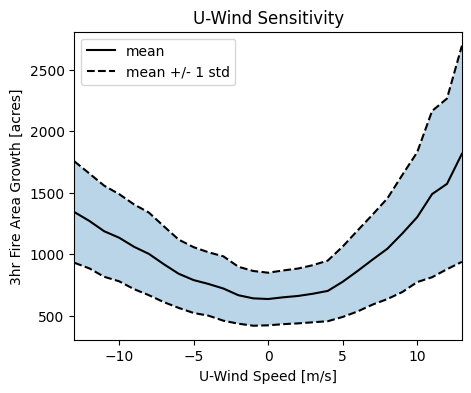

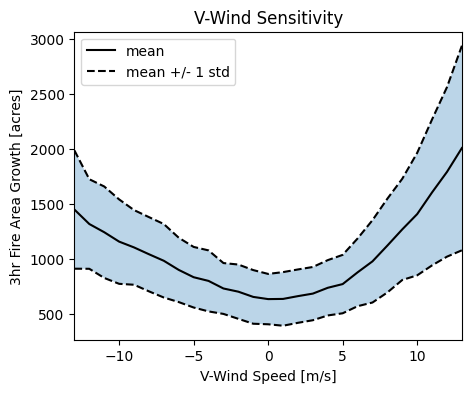

In [289]:
plt.figure(figsize=(5,4))
plt.title('U-Wind Sensitivity')
x = np.arange(-13, 14)
plt.plot(x ,u_mean, color='black', label='mean')
plt.plot(x, u_mean+u_std, color='black',linestyle='dashed', label='mean +/- 1 std')
plt.plot(x, u_mean-u_std, color='black',linestyle='dashed')
plt.xlim(x.min(), x.max())
plt.xlabel('U-Wind Speed [m/s]')
plt.ylabel('3hr Fire Area Growth [acres]')
plt.fill_between(x, u_mean - u_std, u_mean + u_std, alpha=0.3)
plt.legend()

plt.figure(figsize=(5,4))
plt.title('V-Wind Sensitivity')
x = np.arange(-13, 14)
plt.plot(x ,v_mean, color='black', label='mean')
plt.plot(x, v_mean+v_std, color='black',linestyle='dashed', label='mean +/- 1 std')
plt.plot(x, v_mean-v_std, color='black',linestyle='dashed')
plt.xlim(x.min(), x.max())
plt.xlabel('V-Wind Speed [m/s]')
plt.ylabel('3hr Fire Area Growth [acres]')
plt.fill_between(x, v_mean - v_std, v_mean + v_std, alpha=0.3)
plt.legend()

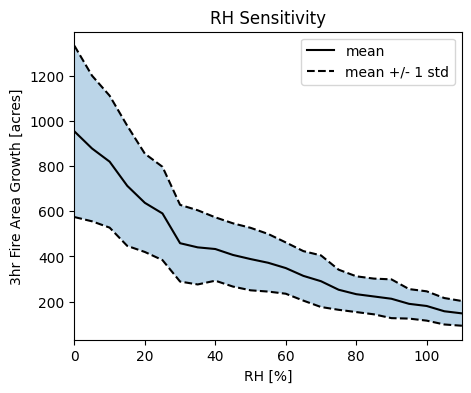

In [290]:
plt.figure(figsize=(5,4))
plt.title('RH Sensitivity')
x=np.arange(0, 115, 5) # (0,110) inclusive
plt.plot(x, rh_mean, color='black', label='mean')
plt.plot(x, rh_mean+rh_std, color='black',linestyle='dashed', label='mean +/- 1 std')
plt.plot(x, rh_mean-rh_std, color='black',linestyle='dashed')
plt.xlim(x.min(), x.max())
plt.xlabel('RH [%]')
plt.ylabel('3hr Fire Area Growth [acres]')
plt.fill_between(x, rh_mean - rh_std, rh_mean + rh_std, alpha=0.3)
plt.legend()

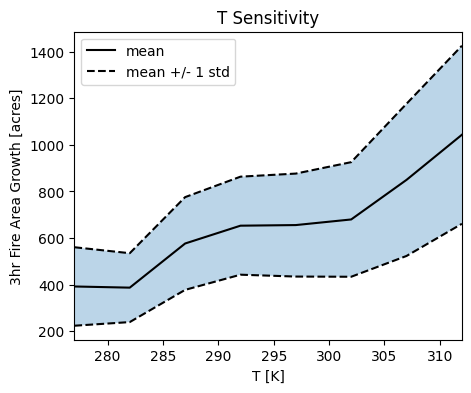

In [291]:
plt.figure(figsize=(5,4))
plt.title('T Sensitivity')
x=np.arange(277, 317, 5)
plt.plot(x ,t_mean, color='black', label='mean')
plt.plot(x, t_mean+t_std, color='black',linestyle='dashed', label='mean +/- 1 std')
plt.plot(x, t_mean-t_std, color='black',linestyle='dashed')
plt.xlim(x.min(), x.max())
plt.xlabel('T [K]')
plt.ylabel('3hr Fire Area Growth [acres]')
plt.fill_between(x, t_mean - t_std, t_mean + t_std, alpha=0.3)
plt.legend()